## Feature Descriptions

| Feature | Description |
|---|---|
| `Gender` | Gender of the passengers (Female, Male) |
| `Customer Type` | The customer type (Loyal customer, disloyal customer) |
| `Age` | The actual age of the passengers |
| `Type of Travel` | Purpose of the flight of the passengers (Personal Travel, Business Travel) |
| `Class` | Travel class in the plane of the passengers (Business, Eco, Eco Plus) |
| `Flight distance` | The flight distance of this journey |
| `Inflight wifi service` | Satisfaction level of the inflight wifi service (0:Not Applicable;1-5) |
| `Departure/Arrival time convenient` | Satisfaction level of Departure/Arrival time convenient |
| `Ease of Online booking` | Satisfaction level of online booking |
| `Gate location` | Satisfaction level of Gate location |
| `Food and drink` | Satisfaction level of Food and drink |
| `Online boarding` | Satisfaction level of online boarding |
| `Seat comfort` | Satisfaction level of Seat comfort |
| `Inflight entertainment` | Satisfaction level of inflight entertainment |
| `On-board service` | Satisfaction level of On-board service |
| `Leg room service` | Satisfaction level of Leg room service |
| `Baggage handling` | Satisfaction level of baggage handling |
| `Check-in service` | Satisfaction level of Check-in service |
| `Inflight service` | Satisfaction level of inflight service |
| `Cleanliness` | Satisfaction level of Cleanliness |
| `Departure Delay in Minutes` | Minutes delayed when departure |
| `Arrival Delay in Minutes` | Minutes delayed when Arrival |
| `Satisfaction` | Airline satisfaction level(Satisfaction, neutral or dissatisfaction) |

## Some Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)

## Cleaning

In [3]:
df = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [4]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [6]:
df.drop(['id'], axis=1, inplace=True)
df.drop(['Unnamed: 0'], axis=1, inplace=True)

test.drop(['id'], axis=1, inplace=True)
test.drop(['Unnamed: 0'], axis=1, inplace=True)

In [7]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Age,103904.0,39.38,15.11,7.0,27.0,40.0,51.0,85.0
Flight Distance,103904.0,1189.45,997.15,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,2.73,1.33,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,3.06,1.53,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,2.76,1.40,0.0,2.0,3.0,4.0,5.0
Gate location,103904.0,2.98,1.28,0.0,2.0,3.0,4.0,5.0
Food and drink,103904.0,3.20,1.33,0.0,2.0,3.0,4.0,5.0
Online boarding,103904.0,3.25,1.35,0.0,2.0,3.0,4.0,5.0
Seat comfort,103904.0,3.44,1.32,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,103904.0,3.36,1.33,0.0,2.0,4.0,4.0,5.0


In [8]:
df.describe(include='object').T

,count,unique,top,freq
Gender,103904,2,Female,52727
Customer Type,103904,2,Loyal Customer,84923
Type of Travel,103904,2,Business travel,71655
Class,103904,3,Business,49665
satisfaction,103904,2,neutral or dissatisfied,58879


In [9]:
df.describe()[['Departure Delay in Minutes']]

,Departure Delay in Minutes
count,103904.000000
mean,14.815618
std,38.230901
min,0.000000
25%,0.000000
50%,0.000000
75%,12.000000
max,1592.000000


In [10]:
print(f'Train Duplicates: {df.duplicated().sum()}')
print(f'Test Duplicates: {test.duplicated().sum()}')

Train Duplicates: 0
Test Duplicates: 0


In [11]:
print(df.isnull().sum()[df.isnull().sum() > 0])
print(test.isnull().sum()[test.isnull().sum() > 0])

Arrival Delay in Minutes    310
dtype: int64
Arrival Delay in Minutes    83
dtype: int64


In [12]:
df['Arrival Delay in Minutes'].fillna(
    df['Departure Delay in Minutes'], inplace=True
)
df['Arrival Delay in Minutes']

0         18.0
1          6.0
2          0.0
3          9.0
4          0.0
          ... 
103899     0.0
103900     0.0
103901    14.0
103902     0.0
103903     0.0
Name: Arrival Delay in Minutes, Length: 103904, dtype: float64

In [13]:
test['Arrival Delay in Minutes'].fillna(
    test['Departure Delay in Minutes'], inplace=True
)
test['Arrival Delay in Minutes']

0        44.0
1         0.0
2         0.0
3         6.0
4        20.0
         ... 
25971     0.0
25972     0.0
25973     0.0
25974     0.0
25975     0.0
Name: Arrival Delay in Minutes, Length: 25976, dtype: float64

In [14]:
print(df.isnull().sum()[df.isnull().sum() > 0])
print(test.isnull().sum()[test.isnull().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


In [15]:
df.dtypes

Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
satisfacti

In [16]:
# In depth check for categorical cols
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class','satisfaction']

for col in categorical_cols:
    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print('-' * 50)

Gender
2
['Male' 'Female']
--------------------------------------------------
Customer Type
2
['Loyal Customer' 'disloyal Customer']
--------------------------------------------------
Type of Travel
2
['Personal Travel' 'Business travel']
--------------------------------------------------
Class
3
['Eco Plus' 'Business' 'Eco']
--------------------------------------------------
satisfaction
2
['neutral or dissatisfied' 'satisfied']
--------------------------------------------------


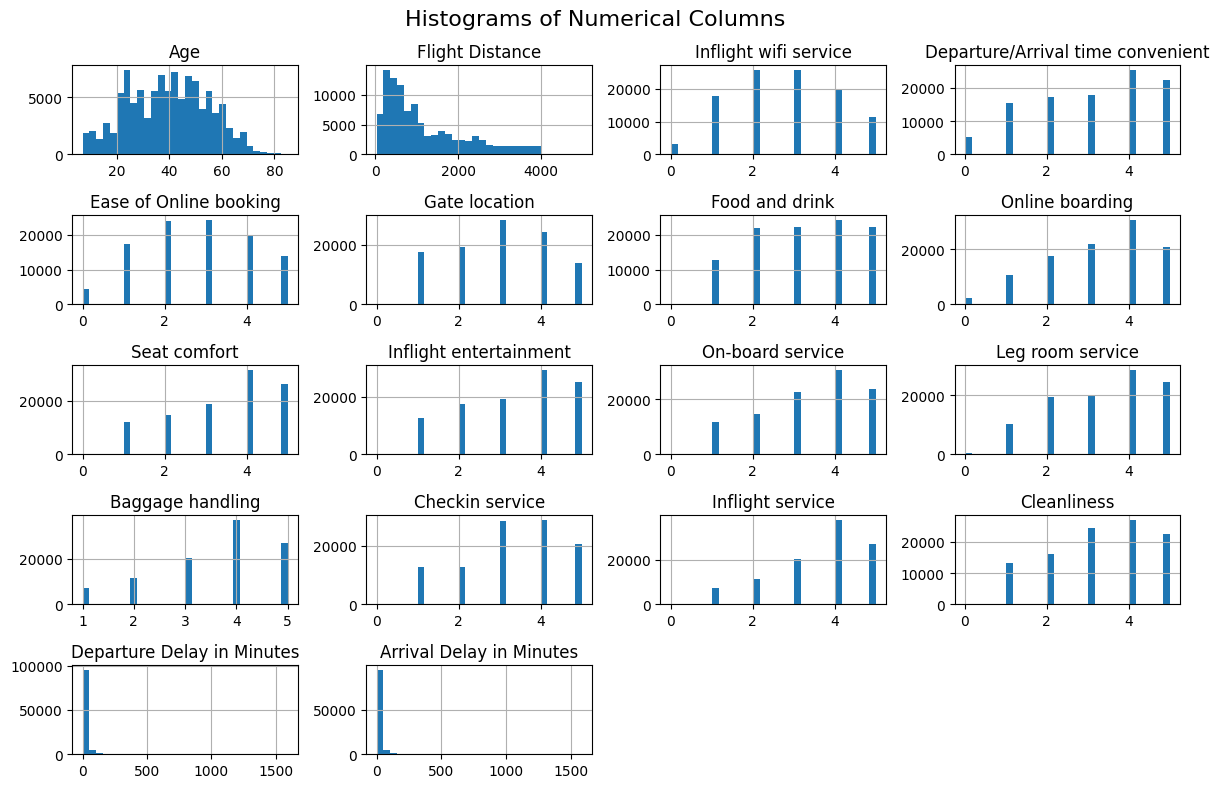

In [17]:
# In depth check for numerical cols
numerical_cols = df.select_dtypes(include='number')

numerical_cols.hist(figsize=(12, 8), bins=30, grid=True)
plt.suptitle('Histograms of Numerical Columns', fontsize=16)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis

In [18]:
# Helper column: 1 = satisfied, 0 = neutral/dissatisfied. Makes .mean() a satisfaction rate.
df['satisfied_num'] = (df['satisfaction'] == 'satisfied').astype(int)

categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
rating_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
               'Ease of Online booking', 'Gate location', 'Food and drink',
               'Online boarding', 'Seat comfort', 'Inflight entertainment',
               'On-board service', 'Leg room service', 'Baggage handling',
               'Checkin service', 'Inflight service', 'Cleanliness']

sns.set_theme(style='whitegrid')

### Q1: Is the target balanced?

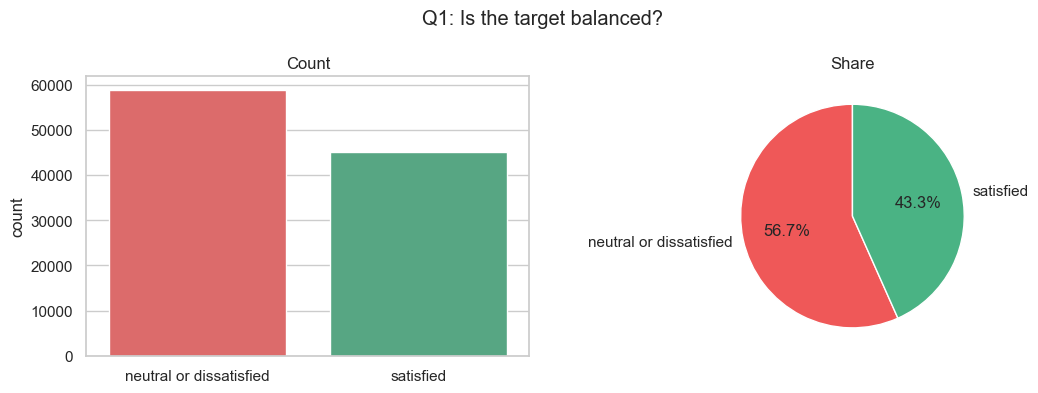

satisfaction
neutral or dissatisfied    56.7
satisfied                  43.3
Name: proportion, dtype: float64


In [19]:
counts = df['satisfaction'].value_counts()
colors = ["#ef5858", "#4ab384"]   # red = dissatisfied, green = satisfied

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df, x='satisfaction', hue='satisfaction',
              palette=colors, legend=False, ax=axes[0])
axes[0].set_title('Count')
axes[0].set_xlabel('')

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Share')

fig.suptitle('Q1: Is the target balanced?')
plt.tight_layout()
plt.show()

print(df['satisfaction'].value_counts(normalize=True).round(3) * 100)

### Q2: Which passenger groups are most satisfied?

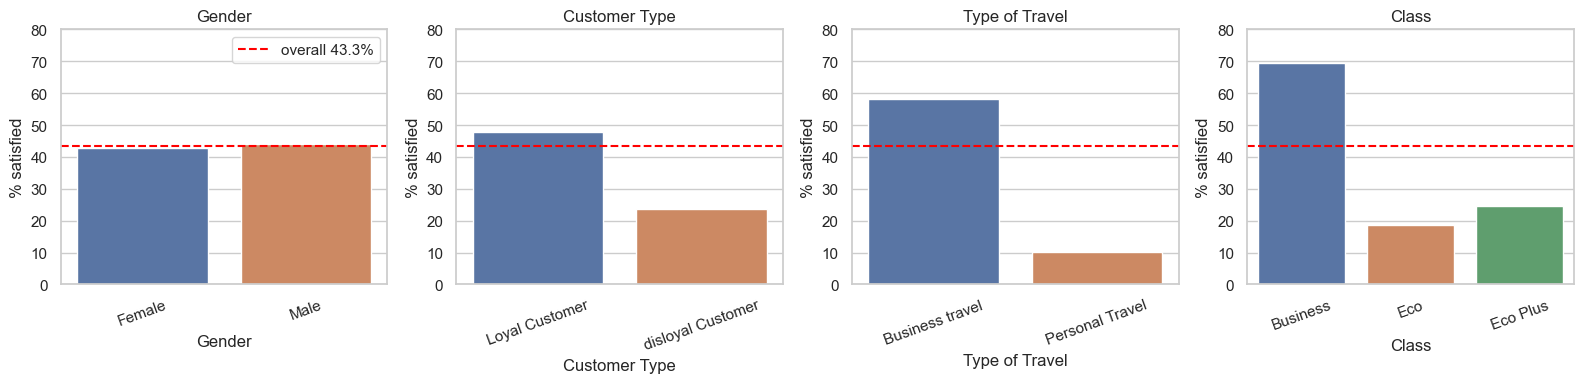

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, categorical_cols):
    rate = df.groupby(col)['satisfied_num'].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax, hue=rate.index)
    ax.axhline(43.3, ls='--', c='red', label='overall 43.3%')
    ax.set_title(col); ax.set_ylabel('% satisfied'); ax.set_ylim(0, 80)
    ax.tick_params(axis='x', rotation=20)
axes[0].legend()
plt.tight_layout()
plt.show()

### Q3: Does age affect satisfaction?

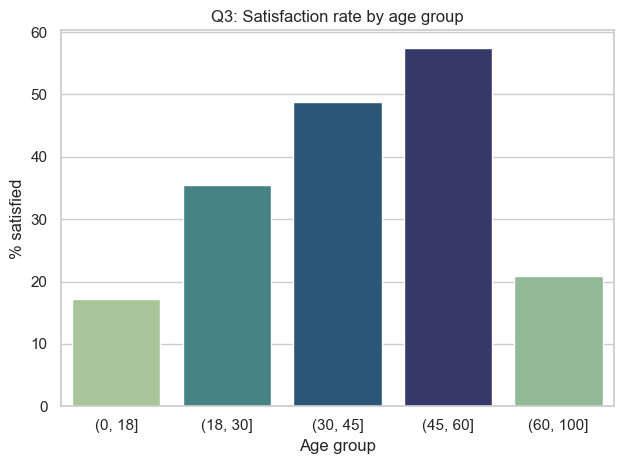

In [21]:
age_bins = pd.cut(df['Age'], bins=[0, 18, 30, 45, 60, 100])
age_sat = df.groupby(age_bins, observed=True)['satisfied_num'].mean() * 100

sns.barplot(x=age_sat.index, y=age_sat.values,
            hue=age_sat.values, palette='crest', legend=False)
plt.title('Q3: Satisfaction rate by age group')
plt.ylabel('% satisfied'); plt.xlabel('Age group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q4: Which services separate satisfied from dissatisfied passengers?

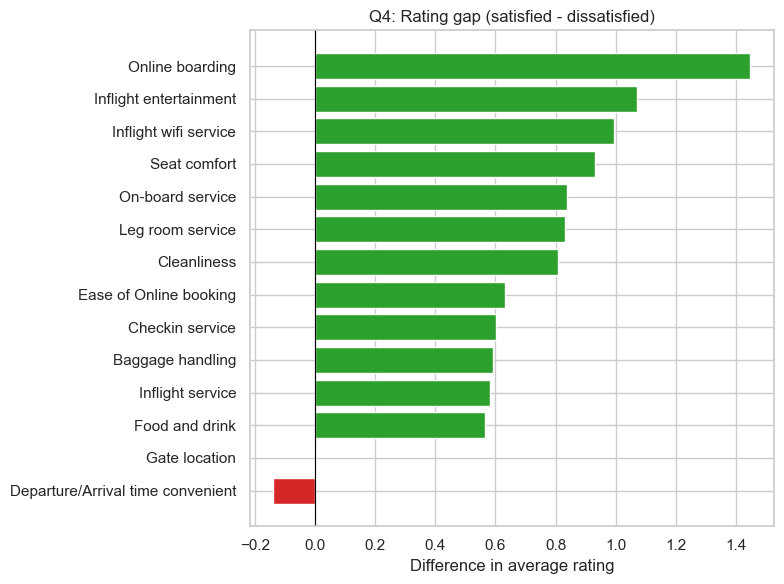

,service,satisfied,dissatisfied,gap
1,Departure/Arrival time convenient,3.15,3.28,-0.14
3,Gate location,2.98,2.98,0.00
4,Food and drink,3.53,2.96,0.56
12,Inflight service,3.97,3.39,0.58
10,Baggage handling,3.97,3.38,0.59
11,Checkin service,3.65,3.04,0.60
2,Ease of Online booking,3.25,2.61,0.63
13,Cleanliness,3.74,2.94,0.81
9,Leg room service,3.84,3.01,0.83
8,On-board service,3.86,3.02,0.84


In [22]:
gap = []
for col in rating_cols:
    s = df.loc[(df['satisfied_num'] == 1) & (df[col] > 0), col].mean()
    d = df.loc[(df['satisfied_num'] == 0) & (df[col] > 0), col].mean()
    gap.append({'service': col, 'satisfied': s, 'dissatisfied': d, 'gap': s - d})

gap = pd.DataFrame(gap).sort_values('gap')

# Green = higher rating among satisfied passengers, red = higher among dissatisfied
colors = ['#d62728' if v < 0 else '#2ca02c' for v in gap['gap']]

plt.figure(figsize=(8, 6))
plt.barh(gap['service'], gap['gap'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Q4: Rating gap (satisfied - dissatisfied)')
plt.xlabel('Difference in average rating')
plt.tight_layout()
plt.show()

gap.round(2)

### Q5: Why does a 0 rating look so strange?

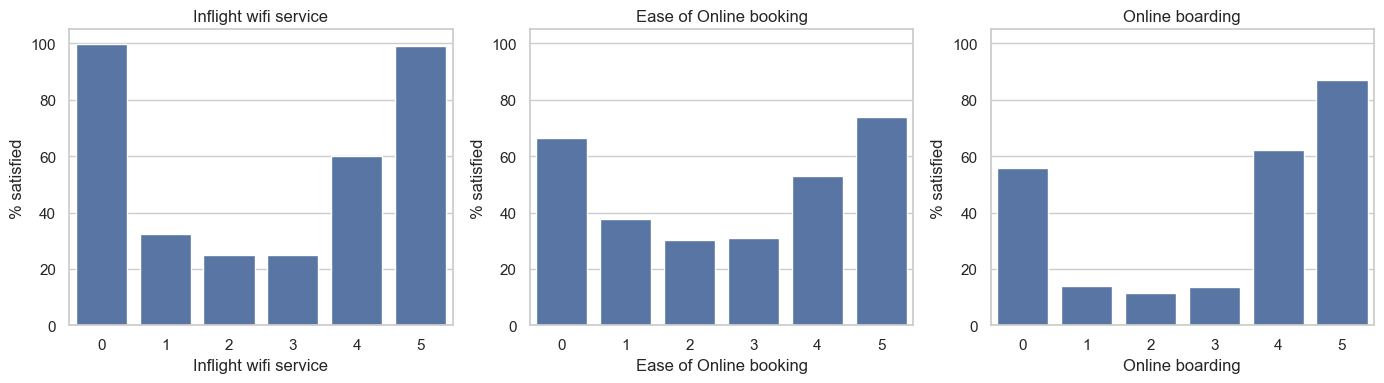

Passengers who rated wifi 0: 3103
Their satisfaction rate: 99.7 %


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Inflight wifi service', 'Ease of Online booking', 'Online boarding']):
    rate = df.groupby(col)['satisfied_num'].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(col); ax.set_ylabel('% satisfied'); ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print('Passengers who rated wifi 0:', (df['Inflight wifi service'] == 0).sum())
print('Their satisfaction rate:',
      round(df.loc[df['Inflight wifi service'] == 0, 'satisfied_num'].mean() * 100, 1), '%')

### Q6: Do flight delays make passengers unhappy?

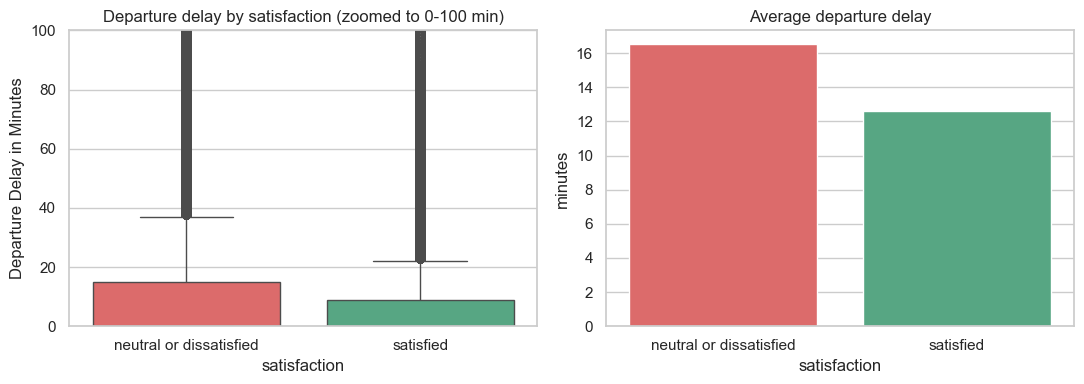

                        Departure Delay in Minutes        \
                                            median  mean   
satisfaction                                               
neutral or dissatisfied                        0.0  16.5   
satisfied                                      0.0  12.6   

                        Arrival Delay in Minutes        
                                          median  mean  
satisfaction                                            
neutral or dissatisfied                      0.0  17.2  
satisfied                                    0.0  12.7  


In [24]:
SAT_COLORS = ["#ef5858", '#4ab384']   # red = neutral/dissatisfied, green = satisfied

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x='satisfaction', y='Departure Delay in Minutes',
            hue='satisfaction', palette=SAT_COLORS, legend=False, ax=axes[0])
axes[0].set_ylim(0, 100)
axes[0].set_title('Departure delay by satisfaction (zoomed to 0-100 min)')

delay_mean = df.groupby('satisfaction')['Departure Delay in Minutes'].mean()
sns.barplot(x=delay_mean.index, y=delay_mean.values,
            hue=delay_mean.index, palette=SAT_COLORS, legend=False, ax=axes[1])
axes[1].set_title('Average departure delay')
axes[1].set_ylabel('minutes')

plt.tight_layout()
plt.show()

print(df.groupby('satisfaction')[['Departure Delay in Minutes',
                                  'Arrival Delay in Minutes']].agg(['median', 'mean']).round(1))

### Q7: Do age and flight distance differ between satisfied and dissatisfied passengers?

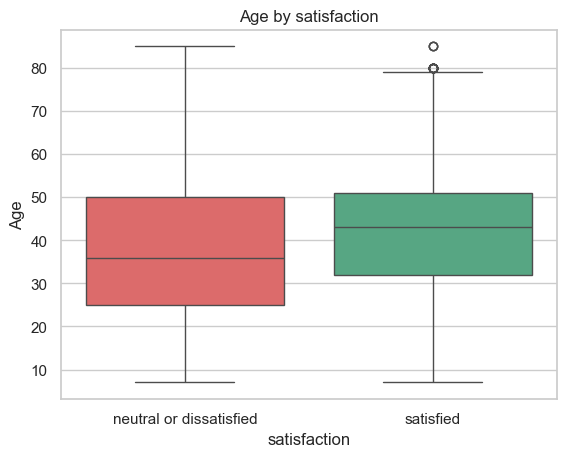

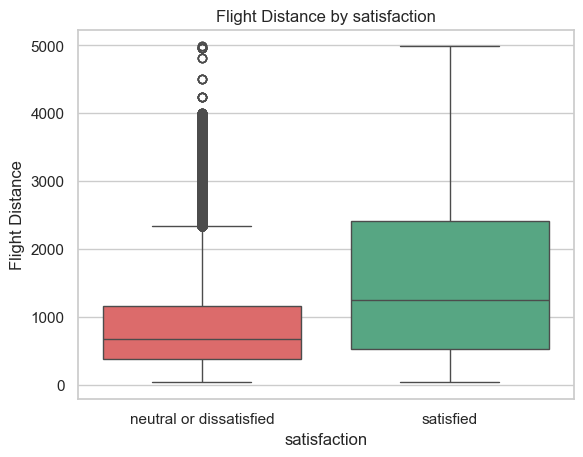

In [25]:
SAT_COLORS = ["#ef5858", '#4ab384']   # red = neutral/dissatisfied, green = satisfied

for col in ['Age', 'Flight Distance']:
    sns.boxplot(data=df, x='satisfaction', y=col,
                hue='satisfaction', palette=SAT_COLORS, legend=False)
    plt.title(f'{col} by satisfaction')
    plt.show()

## Preprocessing

In [26]:
df.drop(['satisfied_num'], axis=1, inplace=True)

In [27]:
# Encode binary categoricals as 0/1 so they can be included in the correlation
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})
df['Customer Type']=df['Customer Type'].map({'Loyal Customer':0,'disloyal Customer':1})
df['Type of Travel']=df['Type of Travel'].map({'Personal Travel':0,'Business travel':1})
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

test['Gender'] = test['Gender'].map({'Male':0,'Female':1})
test['Customer Type']=test['Customer Type'].map({'Loyal Customer':0,'disloyal Customer':1})
test['Type of Travel']=test['Type of Travel'].map({'Personal Travel':0,'Business travel':1})
test['satisfaction'] = test['satisfaction'].map({'neutral or dissatisfied':0,'satisfied':1})

numerical_cols = df.select_dtypes(include='number').columns
corr = df[numerical_cols].corr()

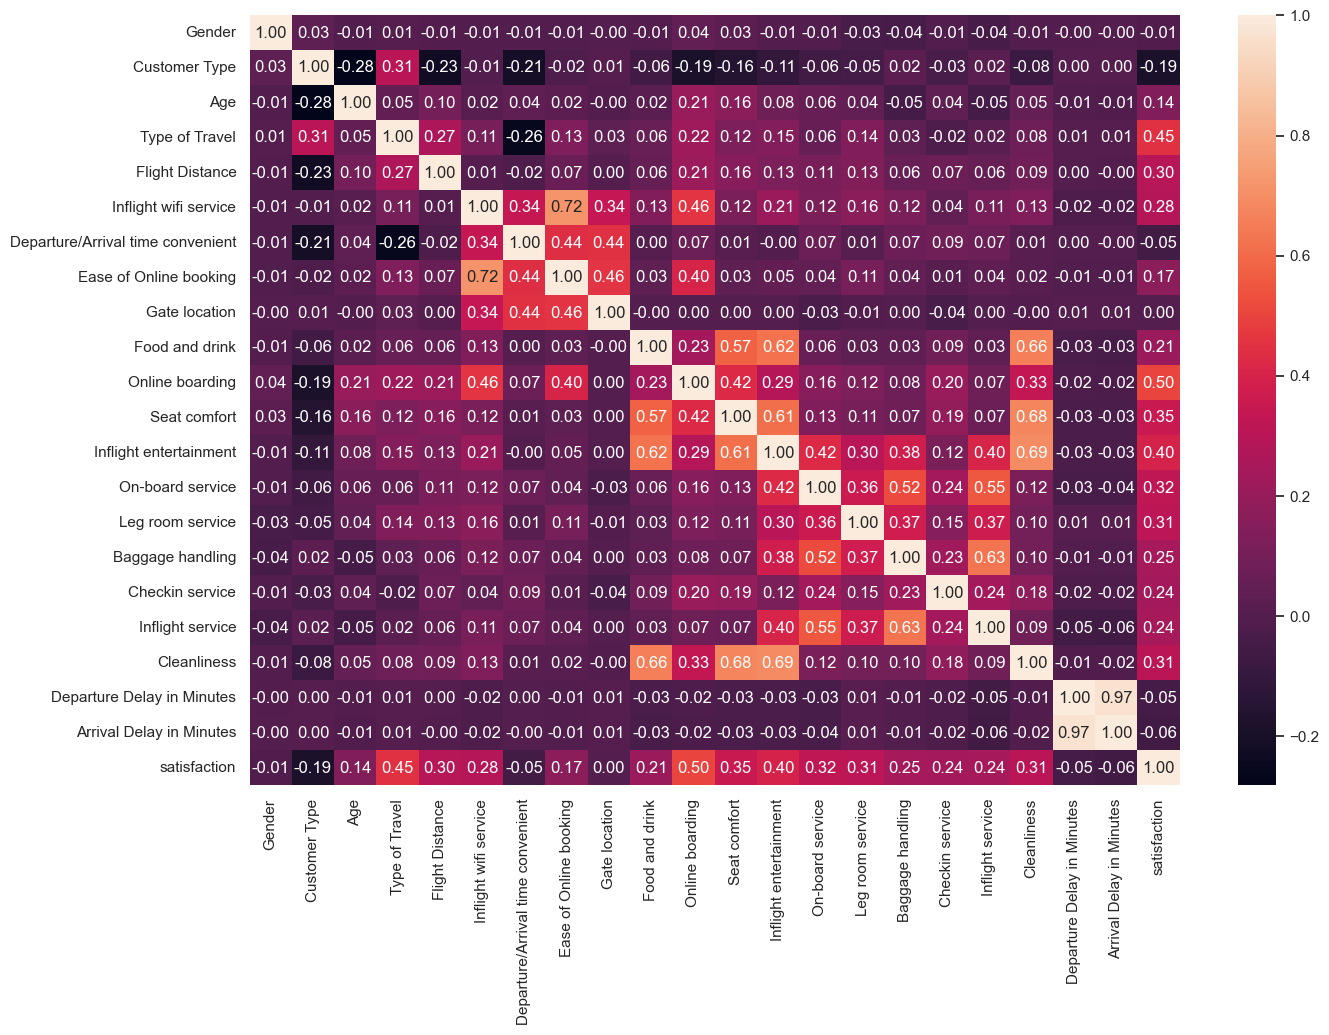

In [28]:
plt.figure(figsize=(15,10))
sns.heatmap(corr,annot = True,fmt='.2f')
plt.show()

In [29]:
df.corr(numeric_only=True)['satisfaction'].abs().sort_values(ascending=False)

satisfaction                         1.000000
Online boarding                      0.503557
Type of Travel                       0.449000
Inflight entertainment               0.398059
Seat comfort                         0.349459
On-board service                     0.322383
Leg room service                     0.313131
Cleanliness                          0.305198
Flight Distance                      0.298780
Inflight wifi service                0.284245
Baggage handling                     0.247749
Inflight service                     0.244741
Checkin service                      0.236174
Food and drink                       0.209936
Customer Type                        0.187638
Ease of Online booking               0.171705
Age                                  0.137167
Arrival Delay in Minutes             0.057522
Departure/Arrival time convenient    0.051601
Departure Delay in Minutes           0.050494
Gender                               0.012211
Gate location                     

In [30]:
# Drop features with near-zero linear correlation to the target
df = df.drop(['Gate location','Gender','Departure Delay in Minutes','Departure/Arrival time convenient','Arrival Delay in Minutes'],axis =1)

test = test.drop(['Gate location','Gender','Departure Delay in Minutes','Departure/Arrival time convenient','Arrival Delay in Minutes'],axis =1)

In [31]:
df

,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Ease of Online booking,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,satisfaction
0,0,13,0,Eco Plus,460,3,3,5,3,5,5,4,3,4,4,5,5,0
1,1,25,1,Business,235,3,3,1,3,1,1,1,5,3,1,4,1,0
2,0,26,1,Business,1142,2,2,5,5,5,5,4,3,4,4,4,5,1
3,0,25,1,Business,562,2,5,2,2,2,2,2,5,3,1,4,2,0
4,0,61,1,Business,214,3,3,4,5,5,3,3,4,4,3,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,1,23,1,Eco,192,2,2,2,2,2,2,3,1,4,2,3,2,0
103900,0,49,1,Business,2347,4,4,2,4,5,5,5,5,5,5,5,4,1
103901,1,30,1,Business,1995,1,1,4,1,5,4,3,2,4,5,5,4,0
103902,1,22,1,Eco,1000,1,1,1,1,1,1,4,5,1,5,4,1,0


In [32]:
# Split the data into training and testing sets
x_train = df.drop(['satisfaction'],axis =1)
x_test = test.drop(['satisfaction'],axis =1)

y_train = df['satisfaction']
y_test =  test['satisfaction']

In [33]:
# Scaling & Encoding
num_cols = x_train.select_dtypes(include= 'number').columns
cat_cols = x_train.select_dtypes(include= 'object').columns

my_transformer = ColumnTransformer([
    ('Numerical', StandardScaler(), num_cols),
    ('Categorical', OneHotEncoder(sparse_output= False, drop= 'first'), cat_cols)
])
my_transformer

,transformers,"[('Numerical', ...), ('Categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [34]:
x_train = my_transformer.fit_transform(x_train)
x_test = my_transformer.transform(x_test)

In [35]:
x_train

array([[-0.4727667 , -1.7452793 , -1.49061375, ...,  1.30586973,
         0.        ,  1.        ],
       [ 2.11520819, -0.95136024,  0.6708646 , ..., -1.74229153,
         0.        ,  0.        ],
       [-0.4727667 , -0.88520032,  0.6708646 , ...,  1.30586973,
         0.        ,  0.        ],
       ...,
       [ 2.11520819, -0.62056063,  0.6708646 , ...,  0.54382941,
         0.        ,  0.        ],
       [ 2.11520819, -1.14984   ,  0.6708646 , ..., -1.74229153,
         1.        ,  0.        ],
       [-0.4727667 , -0.8190404 ,  0.6708646 , ..., -1.74229153,
         0.        ,  0.        ]], shape=(103904, 18))

In [36]:
# Target Encoding
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [37]:
y_train

array([0, 0, 1, ..., 0, 0, 0], shape=(103904,))

## Models

In [38]:
# Function to train the model and evaluate it on train and test data
results = {}

def train_eval(model,x_train,x_test,y_train,y_test,name=None):
    model.fit(x_train,y_train)
    y_pred_train = model.predict(x_train)
    y_pred = model.predict(x_test)

    label = name if name is not None else type(model).__name__
    print("Training Accuracy: ",round(accuracy_score(y_train,y_pred_train)*100,2))
    print("Testing Accuracy: ",round(accuracy_score(y_test,y_pred)*100,2))

    print("\nTrain",label,":\n",classification_report(y_train,y_pred_train))
    print("-"*60)
    print("Test",label,":\n",classification_report(y_test,y_pred))

    # Show the train and test confusion matrices side by side
    fig,axes = plt.subplots(1,2,figsize=(11,4))
    sns.heatmap(confusion_matrix(y_train,y_pred_train),annot=True,fmt='d',ax=axes[0])
    axes[0].set_title("Train "+label)
    sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',ax=axes[1])
    axes[1].set_title("Test "+label)
    plt.tight_layout()
    plt.show()

    # Collect the scores so the models can be compared later
    scores={'Train Accuracy':accuracy_score(y_train,y_pred_train),
            'Test Accuracy':accuracy_score(y_test,y_pred),
            'Precision':precision_score(y_test,y_pred,average='weighted'),
            'Recall':recall_score(y_test,y_pred,average='weighted'),
            'F1 Score':f1_score(y_test,y_pred,average='weighted')}
    if name is not None:
        results[name]=scores

********** Logistic Reggression **********
Training Accuracy:  87.37
Testing Accuracy:  86.94

Train Logistic Regression :
               precision    recall  f1-score   support

           0       0.88      0.90      0.89     58879
           1       0.87      0.84      0.85     45025

    accuracy                           0.87    103904
   macro avg       0.87      0.87      0.87    103904
weighted avg       0.87      0.87      0.87    103904

------------------------------------------------------------
Test Logistic Regression :
               precision    recall  f1-score   support

           0       0.87      0.90      0.89     14573
           1       0.87      0.83      0.85     11403

    accuracy                           0.87     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.87      0.87      0.87     25976



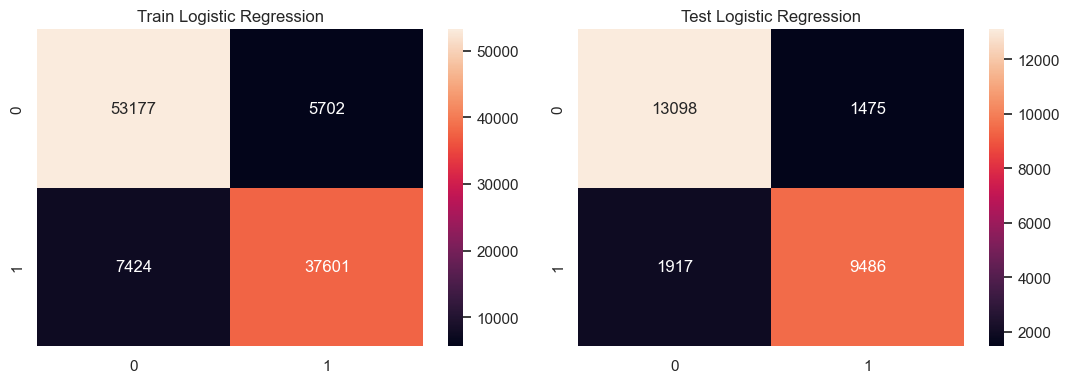

In [39]:
# Logistic Regression
logistic_model=LogisticRegression()
print("*"*10,"Logistic Reggression","*"*10)
train_eval(logistic_model,x_train,x_test,y_train,y_test,name="Logistic Regression")

********** Naive Bayes **********
Training Accuracy:  86.17
Testing Accuracy:  85.87

Train Naive Bayes :
               precision    recall  f1-score   support

           0       0.86      0.90      0.88     58879
           1       0.86      0.81      0.84     45025

    accuracy                           0.86    103904
   macro avg       0.86      0.86      0.86    103904
weighted avg       0.86      0.86      0.86    103904

------------------------------------------------------------
Test Naive Bayes :
               precision    recall  f1-score   support

           0       0.86      0.90      0.88     14573
           1       0.86      0.81      0.83     11403

    accuracy                           0.86     25976
   macro avg       0.86      0.85      0.86     25976
weighted avg       0.86      0.86      0.86     25976



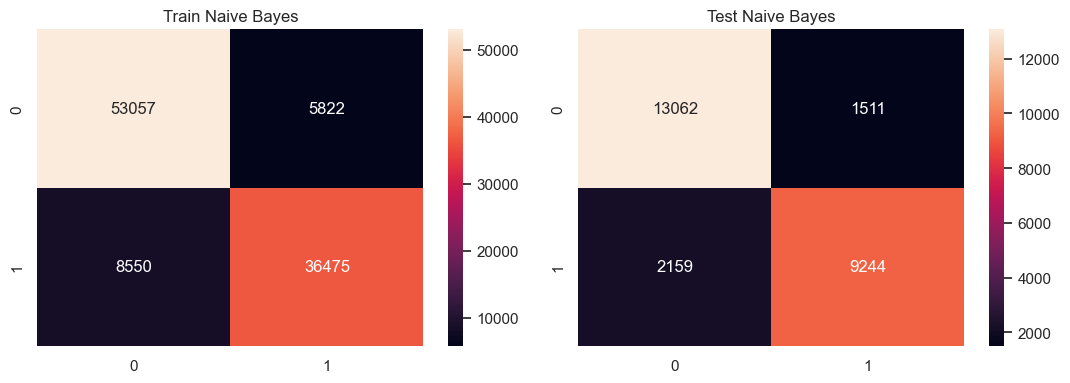

In [40]:
# Naive Bayes
naive_bayes_model=GaussianNB()
print("*"*10,"Naive Bayes","*"*10)
train_eval(naive_bayes_model,x_train,x_test,y_train,y_test,name="Naive Bayes")

********** KNN Model **********
Training Accuracy:  95.35
Testing Accuracy:  93.65

Train KNN :
               precision    recall  f1-score   support

           0       0.94      0.98      0.96     58879
           1       0.97      0.92      0.94     45025

    accuracy                           0.95    103904
   macro avg       0.96      0.95      0.95    103904
weighted avg       0.95      0.95      0.95    103904

------------------------------------------------------------
Test KNN :
               precision    recall  f1-score   support

           0       0.92      0.97      0.94     14573
           1       0.95      0.90      0.93     11403

    accuracy                           0.94     25976
   macro avg       0.94      0.93      0.94     25976
weighted avg       0.94      0.94      0.94     25976



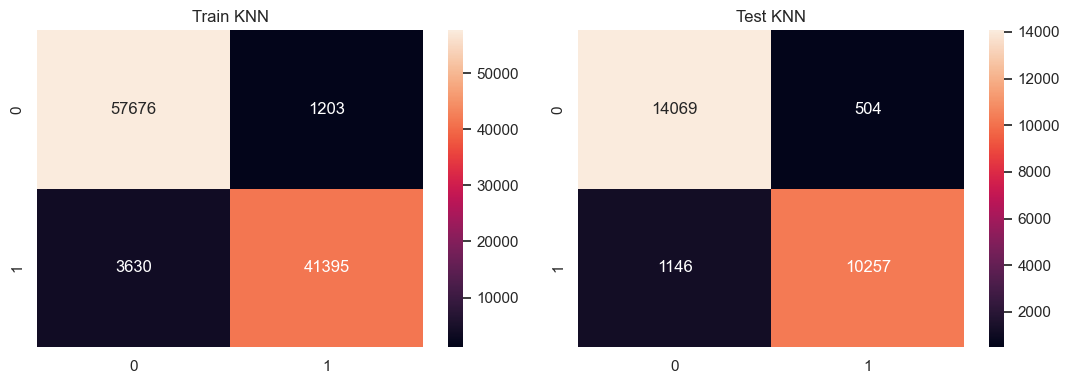

In [41]:
# KNN
knn_model=KNeighborsClassifier(n_neighbors=5)
print("*"*10,"KNN Model","*"*10)
train_eval(knn_model,x_train,x_test,y_train,y_test,name="KNN")

********** SVC **********
Training Accuracy:  95.77
Testing Accuracy:  95.62

Train SVC :
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     58879
           1       0.97      0.94      0.95     45025

    accuracy                           0.96    103904
   macro avg       0.96      0.96      0.96    103904
weighted avg       0.96      0.96      0.96    103904

------------------------------------------------------------
Test SVC :
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     14573
           1       0.96      0.94      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.95      0.96     25976
weighted avg       0.96      0.96      0.96     25976



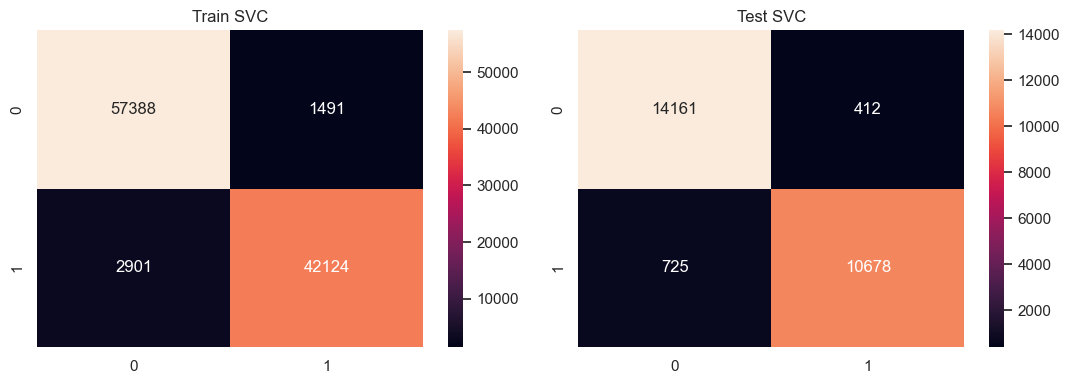

In [42]:
# SVC
svc_model=SVC(random_state=42)
print("*"*10,"SVC","*"*10)
train_eval(svc_model,x_train,x_test,y_train,y_test,name="SVC")

********** SVC With Linear Kernel **********
Training Accuracy:  87.32
Testing Accuracy:  86.9

Train SVC With Linear Kernel :
               precision    recall  f1-score   support

           0       0.88      0.90      0.89     58879
           1       0.87      0.83      0.85     45025

    accuracy                           0.87    103904
   macro avg       0.87      0.87      0.87    103904
weighted avg       0.87      0.87      0.87    103904

------------------------------------------------------------
Test SVC With Linear Kernel :
               precision    recall  f1-score   support

           0       0.87      0.90      0.89     14573
           1       0.87      0.83      0.85     11403

    accuracy                           0.87     25976
   macro avg       0.87      0.86      0.87     25976
weighted avg       0.87      0.87      0.87     25976



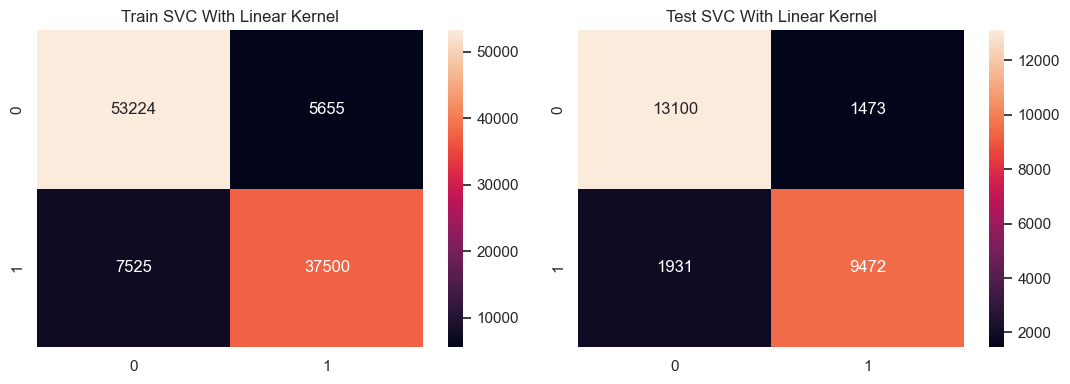

In [43]:
# SVC With Linear Kernel
svc_linear_model=LinearSVC(random_state=42)
print("*"*10,"SVC With Linear Kernel","*"*10)
train_eval(svc_linear_model,x_train,x_test,y_train,y_test,name="SVC With Linear Kernel")

In [44]:
# Decision Tree Hyperparameter Tuning
tree_parms={'criterion':['gini','entropy'],'max_depth':[3,5,7,10,12],"min_samples_split":[2,4,6,8,10]}
grid_search=GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),param_grid=tree_parms,cv=5,n_jobs=-1)
grid_search.fit(x_train,y_train)
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'criterion': 'gini', 'max_depth': 12, 'min_samples_split': 10}


********** Tuned Decision Tree **********
Training Accuracy:  95.87
Testing Accuracy:  95.17

Train Tuned Decision Tree :
               precision    recall  f1-score   support

           0       0.95      0.98      0.96     58879
           1       0.97      0.93      0.95     45025

    accuracy                           0.96    103904
   macro avg       0.96      0.96      0.96    103904
weighted avg       0.96      0.96      0.96    103904

------------------------------------------------------------
Test Tuned Decision Tree :
               precision    recall  f1-score   support

           0       0.94      0.97      0.96     14573
           1       0.96      0.92      0.94     11403

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



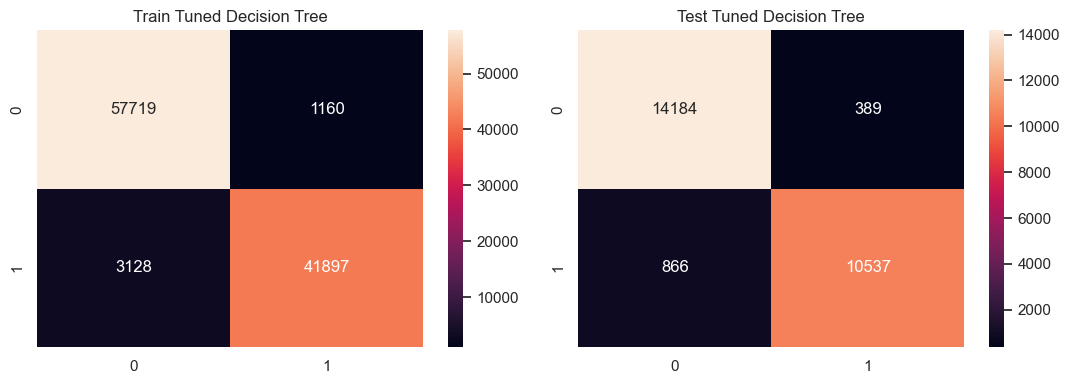

In [45]:
# Tuned Decision Tree
decision_tree_model=DecisionTreeClassifier(criterion="gini",max_depth=12,min_samples_leaf=1,min_samples_split=10,random_state=42)
print("*"*10,"Tuned Decision Tree","*"*10)
train_eval(decision_tree_model,x_train,x_test,y_train,y_test,name="Tuned Decision Tree")

In [46]:
# Random Forest Hyperparameter Tuning
forest_parms={'n_estimators':[100,200,300],'max_depth':[10,15,None],"min_samples_split":[2,5,10]}
grid_search_forest=GridSearchCV(estimator=RandomForestClassifier(random_state=42,n_jobs=-1),param_grid=forest_parms,cv=5,n_jobs=-1)
grid_search_forest.fit(x_train,y_train)
print("Best parameters found: ", grid_search_forest.best_params_)

Best parameters found:  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}


********** Tuned Random Forest **********
Training Accuracy:  99.42
Testing Accuracy:  96.22

Train Tuned Random Forest :
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     58879
           1       1.00      0.99      0.99     45025

    accuracy                           0.99    103904
   macro avg       0.99      0.99      0.99    103904
weighted avg       0.99      0.99      0.99    103904

------------------------------------------------------------
Test Tuned Random Forest :
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



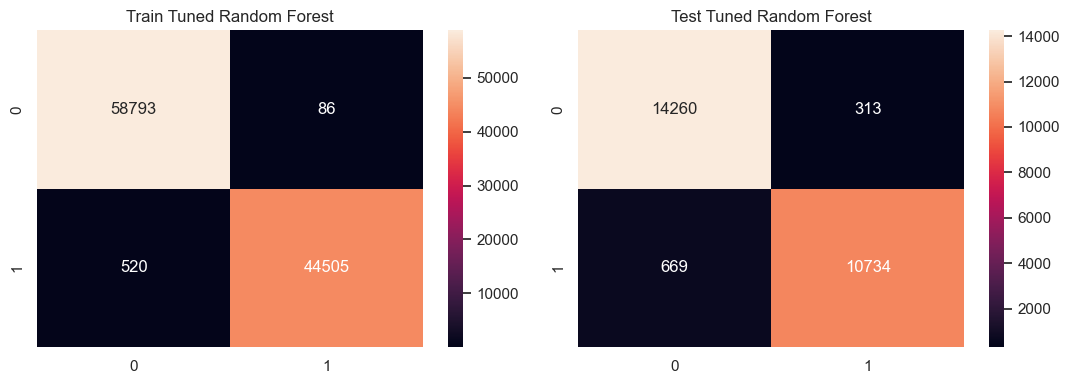

In [47]:
# Tuned Random Forest
random_forest_model=RandomForestClassifier(**grid_search_forest.best_params_, random_state=42, n_jobs=-1)
print("*"*10,"Tuned Random Forest","*"*10)
train_eval(random_forest_model,x_train,x_test,y_train,y_test,name="Tuned Random Forest")

********** AdaBoost **********
Training Accuracy:  92.05
Testing Accuracy:  92.0

Train AdaBoost :
               precision    recall  f1-score   support

           0       0.92      0.94      0.93     58879
           1       0.92      0.89      0.91     45025

    accuracy                           0.92    103904
   macro avg       0.92      0.92      0.92    103904
weighted avg       0.92      0.92      0.92    103904

------------------------------------------------------------
Test AdaBoost :
               precision    recall  f1-score   support

           0       0.92      0.94      0.93     14573
           1       0.92      0.90      0.91     11403

    accuracy                           0.92     25976
   macro avg       0.92      0.92      0.92     25976
weighted avg       0.92      0.92      0.92     25976



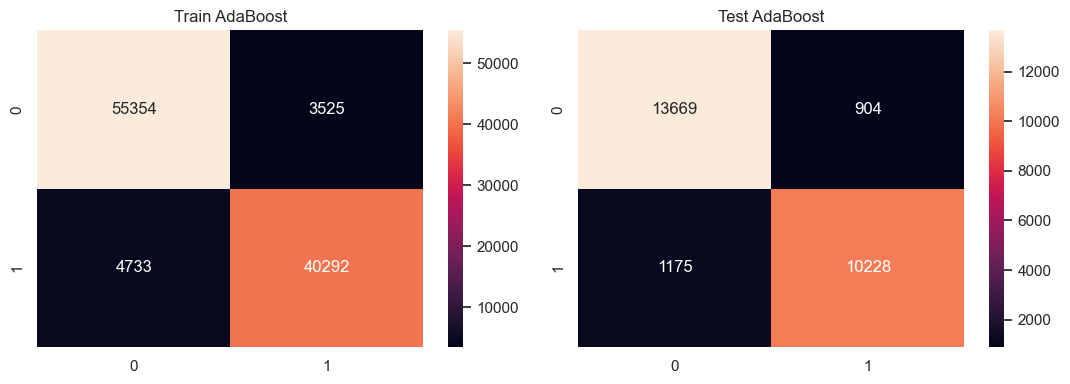

In [48]:
# AdaBoost
ada_boost_model=AdaBoostClassifier(n_estimators=100,learning_rate=1.0,random_state=42)
print("*"*10,"AdaBoost","*"*10)
train_eval(ada_boost_model,x_train,x_test,y_train,y_test,name="AdaBoost")

********** Gradient Boosting **********
Training Accuracy:  94.1
Testing Accuracy:  94.06

Train Gradient Boosting :
               precision    recall  f1-score   support

           0       0.94      0.96      0.95     58879
           1       0.94      0.92      0.93     45025

    accuracy                           0.94    103904
   macro avg       0.94      0.94      0.94    103904
weighted avg       0.94      0.94      0.94    103904

------------------------------------------------------------
Test Gradient Boosting :
               precision    recall  f1-score   support

           0       0.94      0.96      0.95     14573
           1       0.94      0.92      0.93     11403

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



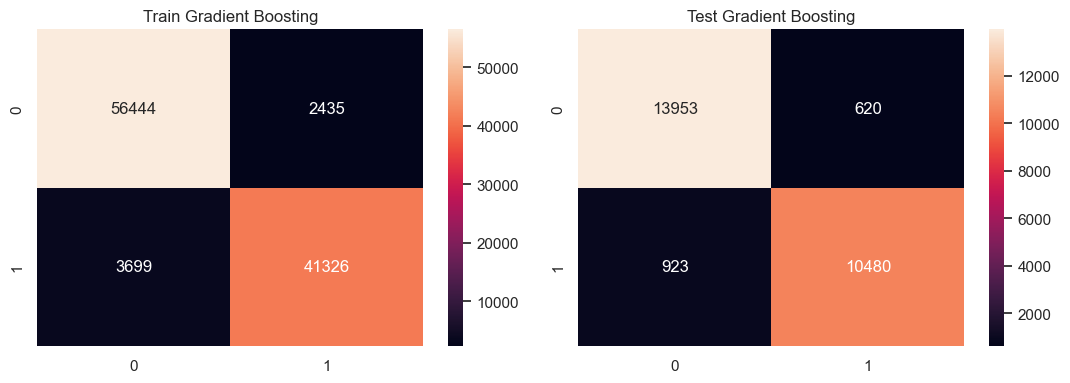

In [49]:
# Gradient Boosting
gradient_boosting_model=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
print("*"*10,"Gradient Boosting","*"*10)
train_eval(gradient_boosting_model,x_train,x_test,y_train,y_test,name="Gradient Boosting")

In [50]:
# XGBoost Hyperparameter Tuning
xgb_parms={'n_estimators':[100,200,300],'learning_rate':[0.01,0.1,0.3],'max_depth':[3,6,9]}
grid_search_xgb=GridSearchCV(estimator=XGBClassifier(random_state=42,n_jobs=-1,eval_metric='logloss'),param_grid=xgb_parms,cv=5,n_jobs=-1)
grid_search_xgb.fit(x_train,y_train)
print("Best parameters found: ", grid_search_xgb.best_params_)

Best parameters found:  {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}


********** Tuned XGBoost **********
Training Accuracy:  98.3
Testing Accuracy:  96.4

Train Tuned XGBoost :
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     58879
           1       0.99      0.97      0.98     45025

    accuracy                           0.98    103904
   macro avg       0.98      0.98      0.98    103904
weighted avg       0.98      0.98      0.98    103904

------------------------------------------------------------
Test Tuned XGBoost :
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



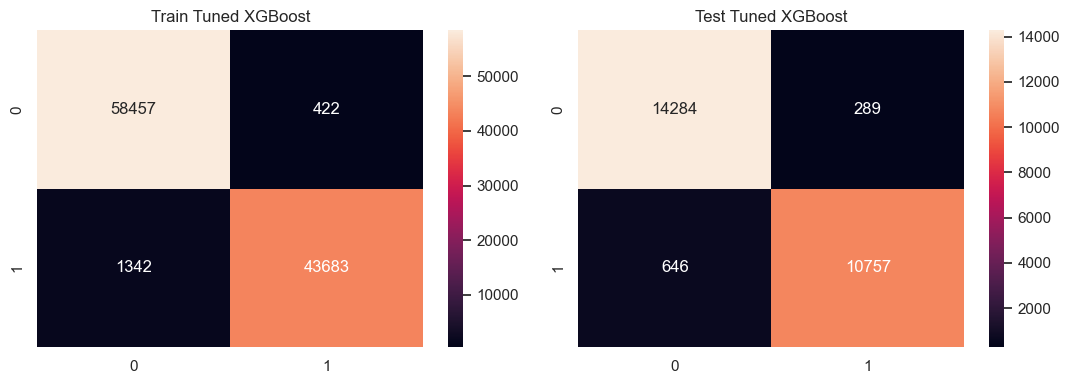

In [51]:
# Tuned XGBoost
xgb_model=XGBClassifier(**grid_search_xgb.best_params_,random_state=42,n_jobs=-1,eval_metric='logloss')
print("*"*10,"Tuned XGBoost","*"*10)
train_eval(xgb_model,x_train,x_test,y_train,y_test,name="Tuned XGBoost")

In [52]:
# LightGBM Hyperparameter Tuning
lgbm_parms={'n_estimators':[100,200,300],'learning_rate':[0.01,0.1,0.3],'num_leaves':[31,50,70]}
grid_search_lgbm=GridSearchCV(estimator=LGBMClassifier(random_state=42,n_jobs=-1,verbose=-1),param_grid=lgbm_parms,cv=5,n_jobs=-1)
grid_search_lgbm.fit(x_train,y_train)
print("Best parameters found: ", grid_search_lgbm.best_params_)

Best parameters found:  {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 70}


********** Tuned LightGBM **********
Training Accuracy:  96.97
Testing Accuracy:  96.39

Train Tuned LightGBM :
               precision    recall  f1-score   support

           0       0.96      0.99      0.97     58879
           1       0.98      0.95      0.96     45025

    accuracy                           0.97    103904
   macro avg       0.97      0.97      0.97    103904
weighted avg       0.97      0.97      0.97    103904

------------------------------------------------------------
Test Tuned LightGBM :
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.98      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



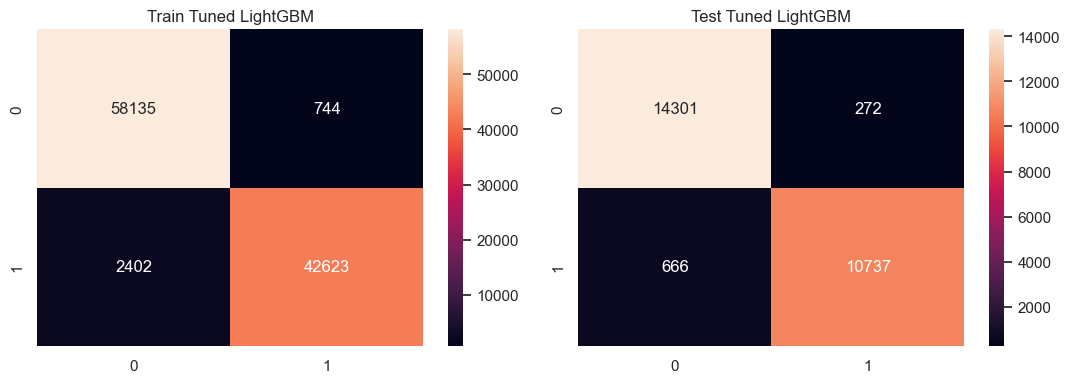

In [53]:
# Tuned LightGBM
lgbm_model=LGBMClassifier(**grid_search_lgbm.best_params_,random_state=42,n_jobs=-1,verbose=-1)
print("*"*10,"Tuned LightGBM","*"*10)
train_eval(lgbm_model,x_train,x_test,y_train,y_test,name="Tuned LightGBM")

In [54]:
# CatBoost Hyperparameter Tuning
cat_parms={'iterations':[100,200,300],'learning_rate':[0.01,0.1,0.3],'depth':[4,6,8]}
grid_search_cat=GridSearchCV(estimator=CatBoostClassifier(random_state=42,verbose=0),param_grid=cat_parms,cv=5,n_jobs=-1)
grid_search_cat.fit(x_train,y_train)
print("Best parameters found: ", grid_search_cat.best_params_)

Best parameters found:  {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}


********** Tuned CatBoost **********
Training Accuracy:  97.34
Testing Accuracy:  96.37

Train Tuned CatBoost :
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     58879
           1       0.98      0.95      0.97     45025

    accuracy                           0.97    103904
   macro avg       0.97      0.97      0.97    103904
weighted avg       0.97      0.97      0.97    103904

------------------------------------------------------------
Test Tuned CatBoost :
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



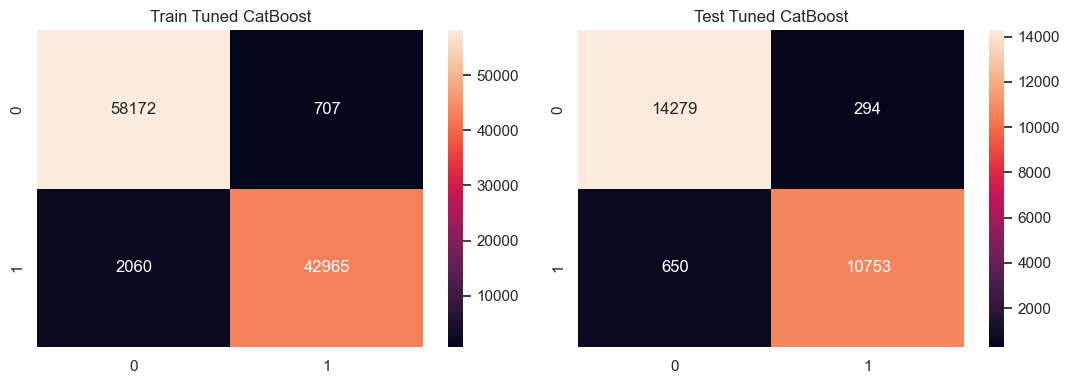

In [55]:
# Tuned CatBoost
cat_model=CatBoostClassifier(**grid_search_cat.best_params_,random_state=42,verbose=0)
print("*"*10,"Tuned CatBoost","*"*10)
train_eval(cat_model,x_train,x_test,y_train,y_test,name="Tuned CatBoost")

## Model Comparison

In [56]:
# Build the comparison table from the scores collected by train_eval
comparison_df=pd.DataFrame(results).T
comparison_df=comparison_df.sort_values('F1 Score',ascending=False).round(4)
comparison_df.style.format('{:.4f}').background_gradient(subset=['F1 Score'])

,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
Tuned XGBoost,0.9830,0.9640,0.9642,0.9640,0.9639
Tuned LightGBM,0.9697,0.9639,0.9642,0.9639,0.9638
Tuned CatBoost,0.9734,0.9637,0.9639,0.9637,0.9636
Tuned Random Forest,0.9942,0.9622,0.9624,0.9622,0.9621
SVC,0.9577,0.9562,0.9564,0.9562,0.9562
Tuned Decision Tree,0.9587,0.9517,0.9521,0.9517,0.9516
Gradient Boosting,0.9410,0.9406,0.9407,0.9406,0.9405
KNN,0.9535,0.9365,0.9372,0.9365,0.9362
AdaBoost,0.9205,0.9200,0.9199,0.9200,0.9199
Logistic Regression,0.8737,0.8694,0.8693,0.8694,0.8691


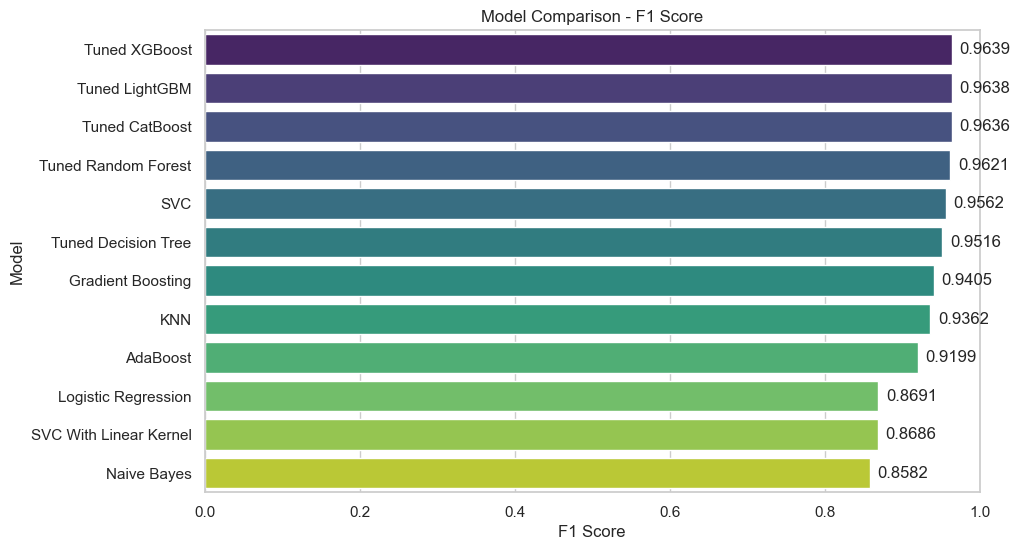

In [57]:
# Compare the models on F1 Score
plt.figure(figsize=(10,6))
sns.barplot(x=comparison_df['F1 Score'],y=comparison_df.index,palette='viridis')
plt.title('Model Comparison - F1 Score')
plt.xlabel('F1 Score')
plt.ylabel('Model')
plt.xlim(0,1)
for i,v in enumerate(comparison_df['F1 Score']):
    plt.text(v+0.01,i,f'{v:.4f}',va='center')
plt.show()

In [58]:
# Best model based on F1 Score
best_model_name=comparison_df['F1 Score'].idxmax()
best_scores=comparison_df.loc[best_model_name]
print("*"*10,"Best Model","*"*10)
print("Model :",best_model_name)
print("Train Accuracy :",round(best_scores['Train Accuracy'],4))
print("Test Accuracy :",round(best_scores['Test Accuracy'],4))
print("Precision :",round(best_scores['Precision'],4))
print("Recall :",round(best_scores['Recall'],4))
print("F1 Score :",round(best_scores['F1 Score'],4))
print("Overfitting Gap :",round(best_scores['Train Accuracy']-best_scores['Test Accuracy'],4))

********** Best Model **********
Model : Tuned XGBoost
Train Accuracy : 0.983
Test Accuracy : 0.964
Precision : 0.9642
Recall : 0.964
F1 Score : 0.9639
Overfitting Gap : 0.019


## Feature Importance

In [59]:
# Map the best model name to its fitted estimator
trained_models={'Logistic Regression':logistic_model,
                'Naive Bayes':naive_bayes_model,
                'KNN':knn_model,
                'SVC':svc_model,
                'SVC With Linear Kernel':svc_linear_model,
                'Tuned Decision Tree':decision_tree_model,
                'Tuned Random Forest':random_forest_model,
                'AdaBoost':ada_boost_model,
                'Gradient Boosting':gradient_boosting_model,
                'Tuned XGBoost':xgb_model,
                'Tuned LightGBM':lgbm_model,
                'Tuned CatBoost':cat_model}

best_model=trained_models[best_model_name]
feature_names=[c.split('__')[-1] for c in my_transformer.get_feature_names_out()]
print("Best Model :",best_model_name)

Best Model : Tuned XGBoost


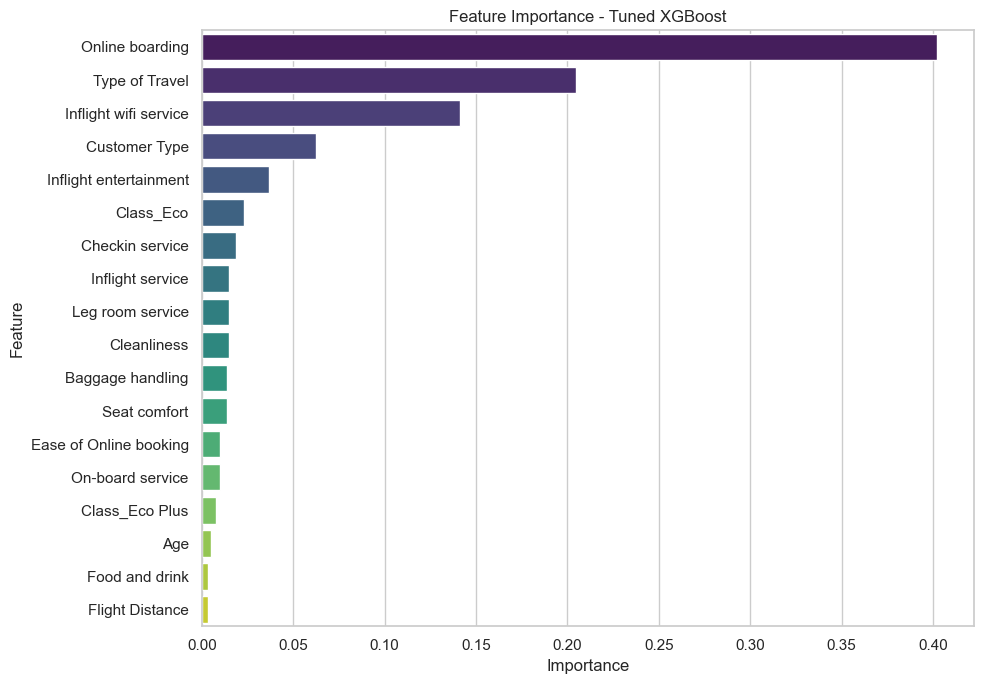

Top 10 Features :

Online boarding           0.4023
Type of Travel            0.2045
Inflight wifi service     0.1411
Customer Type             0.0624
Inflight entertainment    0.0368
Class_Eco                 0.0229
Checkin service           0.0185
Inflight service          0.0151
Leg room service          0.0148
Cleanliness               0.0146
dtype: float32


In [60]:
# Feature importance of the best model
importance=pd.Series(best_model.feature_importances_,index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(x=importance,y=importance.index,palette='viridis')
plt.title('Feature Importance - '+best_model_name)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 10 Features :\n")
print(importance.head(10).round(4))

## Conclusion

In [61]:
# Final summary of the project
print("*"*20,"Project Summary","*"*20)
print("Rows (train | test) :",x_train.shape[0],"|",x_test.shape[0])
print("Features used       :",x_train.shape[1])
print("Models trained      :",len(results))
print("-"*60)
print("Best Model    :",best_model_name)
print("Test Accuracy :",round(best_scores['Test Accuracy']*100,2),"%")
print("F1 Score      :",round(best_scores['F1 Score']*100,2),"%")
print("-"*60)
print("Top 5 Drivers of Satisfaction :")
for rank,(feature,score) in enumerate(importance.head(5).items(),1):
    print("  ",rank,"-",feature,":",round(score,4))

******************** Project Summary ********************
Rows (train | test) : 103904 | 25976
Features used       : 18
Models trained      : 12
------------------------------------------------------------
Best Model    : Tuned XGBoost
Test Accuracy : 96.4 %
F1 Score      : 96.39 %
------------------------------------------------------------
Top 5 Drivers of Satisfaction :
   1 - Online boarding : 0.4023
   2 - Type of Travel : 0.2045
   3 - Inflight wifi service : 0.1411
   4 - Customer Type : 0.0624
   5 - Inflight entertainment : 0.0368


## Saving The Best Model

In [62]:
# ! pip install joblib

In [63]:
# Save the best model together with the transformer and the label encoder
import joblib

final_pipeline={'model':best_model,
                'transformer':my_transformer,
                'label_encoder':label_encoder,
                'feature_names':feature_names,
                'model_name':best_model_name}

joblib.dump(final_pipeline,'best_model.pkl')
print("Saved :","best_model.pkl")
print("Model :",best_model_name)

Saved : best_model.pkl
Model : Tuned XGBoost


In [64]:
# Load the saved model back and make sure it gives the same results
loaded=joblib.load('best_model.pkl')
loaded_model=loaded['model']

y_pred_loaded=loaded_model.predict(x_test)
print("Loaded Model :",loaded['model_name'])
print("Test Accuracy :",round(accuracy_score(y_test,y_pred_loaded)*100,2),"%")
print("Matches the saved results :",round(accuracy_score(y_test,y_pred_loaded),4)==round(best_scores['Test Accuracy'],4))

Loaded Model : Tuned XGBoost
Test Accuracy : 96.4 %
Matches the saved results : True


In [65]:
# How to use the saved model on new raw data
def predict_satisfaction(new_data):
    saved=joblib.load('best_model.pkl')
    prepared=saved['transformer'].transform(new_data)
    prediction=saved['model'].predict(prepared)
    # The target was mapped to 0/1 during preprocessing, so map it back to text
    return pd.Series(prediction).map({0:'neutral or dissatisfied',1:'satisfied'}).values

# Example on the first 5 rows of the raw test set
sample=test.drop(['satisfaction'],axis=1).head()
print("Predicted :",predict_satisfaction(sample))
print("Actual    :",test['satisfaction'].head().map({0:'neutral or dissatisfied',1:'satisfied'}).values)

Predicted : ['satisfied' 'satisfied' 'neutral or dissatisfied' 'satisfied'
 'neutral or dissatisfied']
Actual    : ['satisfied' 'satisfied' 'neutral or dissatisfied' 'satisfied' 'satisfied']


## Deployment

In [66]:
# Save the comparison table so the Streamlit app can show it
comparison_df.to_csv('model_comparison.csv')
print("Saved : model_comparison.csv")

Saved : model_comparison.csv


In [67]:
%%writefile app.py
# Airline Passenger Satisfaction - Streamlit App
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(page_title="Airline Passenger Satisfaction", page_icon="✈️", layout="wide")

# ---------------------------------------------------------------- palette
TEAL = "#2DD4BF"          # satisfied / positive
ROSE = "#FB7185"          # neutral or dissatisfied / negative
INDIGO = "#818CF8"        # secondary accent
SAT_COLORS = {"neutral or dissatisfied": ROSE, "satisfied": TEAL}
SEQ = ["#1E3A5F", "#2A7B9B", "#2DD4BF"]          # low -> high
DIVERGING = [ROSE, "#4B5563", TEAL]              # negative -> positive

SERVICE_COLS = ['Inflight wifi service', 'Ease of Online booking', 'Food and drink',
                'Online boarding', 'Seat comfort', 'Inflight entertainment',
                'On-board service', 'Leg room service', 'Baggage handling',
                'Checkin service', 'Inflight service', 'Cleanliness']

RATING_COLS = ['Inflight wifi service', 'Departure/Arrival time convenient',
               'Ease of Online booking', 'Gate location', 'Food and drink',
               'Online boarding', 'Seat comfort', 'Inflight entertainment',
               'On-board service', 'Leg room service', 'Baggage handling',
               'Checkin service', 'Inflight service', 'Cleanliness']


def style_fig(fig, height=330, title=None, showlegend=True):
    """One look for every chart: transparent background, tidy margins, compact height."""
    fig.update_layout(
        height=height,
        margin=dict(l=10, r=10, t=45 if title else 20, b=10),
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        showlegend=showlegend,
        legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02),
        font=dict(size=12),
        hoverlabel=dict(font_size=12),
    )
    if title:
        fig.update_layout(title=dict(text=title, font=dict(size=14)))
    fig.update_xaxes(showgrid=False, zeroline=False)
    fig.update_yaxes(showgrid=True, gridcolor="rgba(128,128,128,0.15)", zeroline=False)
    return fig


@st.cache_resource
def load_model():
    return joblib.load('best_model.pkl')


@st.cache_data
def load_data():
    df = pd.read_csv('data/train.csv')
    df = df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')
    df['satisfied_num'] = (df['satisfaction'] == 'satisfied').astype(int)
    return df


@st.cache_data
def test_predictions():
    """Score the untouched test set so the home page can show a real confusion matrix."""
    raw = pd.read_csv('data/test.csv')
    y_true = (raw['satisfaction'] == 'satisfied').astype(int)
    x = raw.copy()
    x['Customer Type'] = x['Customer Type'].map({'Loyal Customer': 0, 'disloyal Customer': 1})
    x['Type of Travel'] = x['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})
    x = x[list(transformer.feature_names_in_)]
    x = x.fillna(x.median(numeric_only=True))
    return y_true.values, model.predict(transformer.transform(x))


@st.cache_resource
def load_explainer(_model):
    import shap
    return shap.TreeExplainer(_model)


saved = load_model()
model = saved['model']
transformer = saved['transformer']
model_name = saved['model_name']

st.sidebar.title("✈️ Airline Satisfaction")
page = st.sidebar.radio("Go to", ["🏠 Home", "📊 EDA", "🔮 Prediction"])
st.sidebar.markdown("---")
st.sidebar.caption("Predicting airline passenger satisfaction from trip details "
                   "and service ratings.")


# -------------------------------------------------------------------- Home
if page == "🏠 Home":
    st.title("✈️ Airline Passenger Satisfaction")
    st.write("Predicting whether an airline passenger will be satisfied, from their trip "
             "details and the ratings they give to each service.")

    try:
        comparison = pd.read_csv('model_comparison.csv', index_col=0)
        best = comparison.loc[model_name]
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Best Model", model_name.replace("Tuned ", ""))
        c2.metric("Test Accuracy", f"{best['Test Accuracy']*100:.2f} %")
        c3.metric("F1 Score", f"{best['F1 Score']*100:.2f} %")
        c4.metric("Overfitting Gap", f"{(best['Train Accuracy']-best['Test Accuracy'])*100:.2f} %")
        st.caption(f"Chosen by F1 score out of {len(comparison)} trained models.")
    except FileNotFoundError:
        comparison = None
        st.info("Run the notebook cell that saves model_comparison.csv to see the comparison.")

    st.markdown("---")
    st.header("Key Insights")
    c1, c2, c3 = st.columns(3)
    with c1:
        st.markdown("#### 🛫 Online boarding leads")
        st.write("It shows the widest rating gap between satisfied and dissatisfied "
                 "passengers, and the model leans on it more than any other feature.")
    with c2:
        st.markdown("#### 💼 Business travel wins")
        st.write("Business travellers and loyal customers are far more satisfied than "
                 "personal travellers and first-time flyers.")
    with c3:
        st.markdown("#### ⏱️ Delays matter less")
        st.write("Median delay is 0 minutes for both groups, so delay is a weak signal "
                 "next to the service ratings.")

    st.markdown("---")
    st.header("Model Performance")

    if comparison is not None:
        c1, c2 = st.columns([1, 1])
        with c1:
            st.subheader("All models")
            st.dataframe(comparison.style.format("{:.4f}")
                         .background_gradient(subset=['F1 Score'], cmap='BuGn'),
                         use_container_width=True, height=330)
        with c2:
            st.subheader("F1 score by model")
            ordered = comparison.sort_values('F1 Score')
            data = pd.DataFrame({'Model': ordered.index, 'F1 Score': ordered['F1 Score'].values})
            fig = px.bar(data, x='F1 Score', y='Model', orientation='h',
                         color='F1 Score', color_continuous_scale=SEQ)
            fig.update_layout(coloraxis_showscale=False, yaxis_title=None)
            fig.update_xaxes(range=[0, 1])
            st.plotly_chart(style_fig(fig, 330, showlegend=False), use_container_width=True)

    c1, c2 = st.columns(2)
    with c1:
        st.subheader("Where it gets things wrong")
        y_true, y_pred = test_predictions()
        cm = pd.crosstab(pd.Series(y_true, name='Actual'), pd.Series(y_pred, name='Predicted'))
        labels = ['Dissatisfied', 'Satisfied']
        fig = px.imshow(cm.values, text_auto='d', color_continuous_scale=SEQ,
                        x=labels, y=labels, labels=dict(x="Predicted", y="Actual"))
        fig.update_traces(textfont_size=18, hovertemplate=
                          "Actual %{y}, predicted %{x}: %{z:,}<extra></extra>")
        fig.update_layout(coloraxis_showscale=False)
        fig.update_xaxes(tickangle=0, side='bottom')
        fig.update_yaxes(showgrid=False)
        st.plotly_chart(style_fig(fig, 340, showlegend=False), use_container_width=True)
        errors = int((y_true != y_pred).sum())
        st.caption(f"On the {len(y_true):,} unseen test passengers the model gets "
                   f"**{errors:,}** wrong ({errors/len(y_true)*100:.2f}%).")
    with c2:
        if hasattr(model, 'feature_importances_'):
            st.subheader("What the model relies on")
            names = [c.split('__')[-1] for c in transformer.get_feature_names_out()]
            imp = pd.Series(model.feature_importances_, index=names).sort_values().tail(10)
            data = pd.DataFrame({'Feature': imp.index, 'Importance': imp.values})
            fig = px.bar(data, x='Importance', y='Feature', orientation='h',
                         color='Importance', color_continuous_scale=SEQ)
            fig.update_layout(coloraxis_showscale=False, yaxis_title=None)
            st.plotly_chart(style_fig(fig, 340, showlegend=False), use_container_width=True)
            st.caption(f"The strongest driver of satisfaction is **{imp.index[-1]}**.")

    st.markdown("---")
    st.header("How It Works")
    c1, c2, c3, c4 = st.columns(4)
    for col, (step, text) in zip([c1, c2, c3, c4], [
            ("1 · Clean", "Drop the id column, fill missing arrival delays with the median, "
                          "and check for duplicates."),
            ("2 · Explore", "Seven questions about who is satisfied and which services "
                            "separate the two groups."),
            ("3 · Prepare", "Drop five weakly correlated features, scale the numbers and "
                            "one-hot encode the class."),
            ("4 · Model", "Train and tune several models, then keep the one with the "
                          "best F1 score.")]):
        with col:
            st.markdown(f"**{step}**")
            st.caption(text)

    st.markdown("---")
    st.caption("Use the sidebar to explore the data or predict a passenger's satisfaction.")


# --------------------------------------------------------------------- EDA
elif page == "📊 EDA":
    st.title("📊 Exploratory Data Analysis")
    df = load_data()

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Passengers", f"{len(df):,}")
    c2.metric("Satisfied", f"{df['satisfied_num'].mean()*100:.1f} %")
    c3.metric("Features", df.shape[1] - 2)
    c4.metric("Average age", f"{df['Age'].mean():.0f}")
    st.markdown("---")

    # Q1
    st.subheader("Q1: Is the target balanced?")
    c1, c2 = st.columns(2)
    counts = df['satisfaction'].value_counts()
    with c1:
        fig = px.pie(values=counts.values, names=counts.index, hole=0,
                     color=counts.index, color_discrete_map=SAT_COLORS)
        fig.update_traces(textposition='inside', textinfo='percent')
        st.plotly_chart(style_fig(fig, 300, "Share"), use_container_width=True)
    with c2:
        data = pd.DataFrame({'satisfaction': counts.index, 'Passengers': counts.values})
        fig = px.bar(data, x='satisfaction', y='Passengers', color='satisfaction',
                     color_discrete_map=SAT_COLORS)
        fig.update_layout(xaxis_title=None)
        st.plotly_chart(style_fig(fig, 300, "Count", showlegend=False), use_container_width=True)
    st.caption(f"The target leans slightly to dissatisfied: "
               f"**{(1-df['satisfied_num'].mean())*100:.1f}%** against "
               f"**{df['satisfied_num'].mean()*100:.1f}%** satisfied — close enough to balanced "
               "that accuracy and F1 stay meaningful.")

    # Q2
    st.subheader("Q2: Which passenger groups are most satisfied?")
    overall = df['satisfied_num'].mean() * 100
    groups = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
    for pair in [groups[:2], groups[2:]]:
        for col_box, group in zip(st.columns(2), pair):
            rate = (df.groupby(group)['satisfied_num'].mean().sort_values() * 100)
            data = pd.DataFrame({group: rate.index.astype(str), '% satisfied': rate.values})
            fig = px.bar(data, x='% satisfied', y=group, orientation='h',
                         color='% satisfied', color_continuous_scale=SEQ)
            fig.add_vline(x=overall, line_dash="dash", line_color="grey")
            fig.update_layout(coloraxis_showscale=False, yaxis_title=None)
            fig.update_xaxes(range=[0, 100])
            with col_box:
                st.plotly_chart(style_fig(fig, 250, group, showlegend=False),
                                use_container_width=True)
    st.caption(f"Business travellers and loyal customers stand out; the dashed line is the "
               f"overall rate of {overall:.1f}%. Gender barely moves the needle.")

    # Q3
    st.subheader("Q3: Does age affect satisfaction?")
    age_bins = pd.cut(df['Age'], bins=[0, 18, 30, 45, 60, 100])
    age_sat = df.groupby(age_bins, observed=True)['satisfied_num'].mean() * 100
    data = pd.DataFrame({'Age group': age_sat.index.astype(str), '% satisfied': age_sat.values})
    fig = px.bar(data, x='Age group', y='% satisfied',
                 color='% satisfied', color_continuous_scale=SEQ)
    fig.update_layout(coloraxis_showscale=False)
    st.plotly_chart(style_fig(fig, 300, showlegend=False), use_container_width=True)
    st.caption("Satisfaction peaks in the 45-60 group and drops sharply for the youngest "
               "and oldest passengers.")

    # Q4
    st.subheader("Q4: Which services separate satisfied from dissatisfied passengers?")
    gap = []
    for col in RATING_COLS:
        s = df.loc[(df['satisfied_num'] == 1) & (df[col] > 0), col].mean()
        d = df.loc[(df['satisfied_num'] == 0) & (df[col] > 0), col].mean()
        gap.append({'service': col, 'satisfied': s, 'dissatisfied': d, 'gap': s - d})
    gap_df = pd.DataFrame(gap).sort_values('gap')
    fig = px.bar(gap_df, x='gap', y='service', orientation='h',
                 color='gap', color_continuous_scale=DIVERGING, color_continuous_midpoint=0,
                 labels={'gap': 'Difference in average rating', 'service': ''})
    fig.add_vline(x=0, line_color="grey")
    fig.update_layout(coloraxis_showscale=False)
    st.plotly_chart(style_fig(fig, 380, showlegend=False), use_container_width=True)
    top = gap_df.iloc[-1]
    st.caption(f"**{top['service']}** shows the widest gap ({top['gap']:.2f} rating points), "
               "while gate location and time convenience separate the groups the least.")

    # Q5
    st.subheader("Q5: Why does a 0 rating look so strange?")
    cols = st.columns(3)
    for col_box, col in zip(cols, ['Inflight wifi service', 'Ease of Online booking', 'Online boarding']):
        rate = df.groupby(col)['satisfied_num'].mean() * 100
        data = pd.DataFrame({'Rating': rate.index.astype(str), '% satisfied': rate.values})
        fig = px.bar(data, x='Rating', y='% satisfied',
                     color='% satisfied', color_continuous_scale=SEQ)
        fig.update_layout(coloraxis_showscale=False)
        fig.update_yaxes(range=[0, 105])
        with col_box:
            st.plotly_chart(style_fig(fig, 260, col, showlegend=False), use_container_width=True)
    zero_n = int((df['Inflight wifi service'] == 0).sum())
    zero_rate = df.loc[df['Inflight wifi service'] == 0, 'satisfied_num'].mean() * 100
    st.caption(f"A 0 does not behave like a low score: the **{zero_n:,}** passengers who rated "
               f"wifi 0 are **{zero_rate:.1f}%** satisfied, far above those who rated it 1. "
               "A 0 means the service was not used rather than badly rated.")

    # Q6
    st.subheader("Q6: Do flight delays make passengers unhappy?")
    c1, c2 = st.columns(2)
    with c1:
        fig = px.box(df, x='satisfaction', y='Departure Delay in Minutes',
                     color='satisfaction', color_discrete_map=SAT_COLORS)
        fig.update_yaxes(range=[0, 100])
        fig.update_layout(xaxis_title=None)
        st.plotly_chart(style_fig(fig, 300, "Departure delay (0-100 min)", showlegend=False),
                        use_container_width=True)
    with c2:
        delay = df.groupby('satisfaction')[['Departure Delay in Minutes',
                                            'Arrival Delay in Minutes']].mean().reset_index()
        delay = delay.melt(id_vars='satisfaction', var_name='Delay', value_name='Minutes')
        fig = px.bar(delay, x='Delay', y='Minutes', color='satisfaction',
                     barmode='group', color_discrete_map=SAT_COLORS)
        fig.update_layout(xaxis_title=None)
        st.plotly_chart(style_fig(fig, 300, "Average delay"), use_container_width=True)
    st.caption("Median delay is 0 minutes for both groups and the means differ by only a few "
               "minutes, so delay is a weak signal compared with the service ratings.")

    # Q7
    st.subheader("Q7: Do age and flight distance differ between the two groups?")
    c1, c2 = st.columns(2)
    for col_box, col in zip([c1, c2], ['Age', 'Flight Distance']):
        fig = px.box(df, x='satisfaction', y=col, color='satisfaction',
                     color_discrete_map=SAT_COLORS)
        fig.update_layout(xaxis_title=None)
        with col_box:
            st.plotly_chart(style_fig(fig, 300, col, showlegend=False), use_container_width=True)
    st.caption("Satisfied passengers skew a little older and fly noticeably longer distances, "
               "which fits the business-travel pattern seen in Q2.")


# -------------------------------------------------------------- Prediction
else:
    st.title("🔮 Passenger Satisfaction Prediction")
    tab_one, tab_batch = st.tabs(["One passenger", "Upload a CSV"])

    with tab_one:
     st.write("Fill in the passenger details below to predict whether they will be satisfied.")

     with st.form("passenger_form"):
         st.subheader("Passenger Information")
         c1, c2, c3 = st.columns(3)
         with c1:
             age = st.number_input("Age", min_value=1, max_value=100, value=40)
             customer_type = st.selectbox("Customer Type", ["Loyal Customer", "disloyal Customer"])
         with c2:
             type_of_travel = st.selectbox("Type of Travel", ["Business travel", "Personal Travel"])
             travel_class = st.selectbox("Class", ["Business", "Eco", "Eco Plus"])
         with c3:
             flight_distance = st.number_input("Flight Distance", min_value=1, max_value=5000, value=1200)

         st.subheader("Service Ratings")
         st.caption("0 means not applicable, 1 is the worst and 5 is the best.")
         ratings = {}
         cols = st.columns(3)
         for i, col_name in enumerate(SERVICE_COLS):
             with cols[i % 3]:
                 ratings[col_name] = st.slider(col_name, 0, 5, 3)

         submitted = st.form_submit_button("Predict Satisfaction", use_container_width=True)

     if submitted:
         # Build one row in exactly the format the transformer was fitted on
         row = {'Customer Type': 0 if customer_type == "Loyal Customer" else 1,
                'Age': age,
                'Type of Travel': 1 if type_of_travel == "Business travel" else 0,
                'Class': travel_class,
                'Flight Distance': flight_distance}
         row.update(ratings)
         new_data = pd.DataFrame([row])[list(transformer.feature_names_in_)]

         prepared = transformer.transform(new_data)
         prediction = int(model.predict(prepared)[0])
         proba = model.predict_proba(prepared)[0]

         st.markdown("---")
         if prediction == 1:
             st.success("### Prediction : Satisfied 😀")
         else:
             st.error("### Prediction : Neutral or Dissatisfied 😕")

         c1, c2 = st.columns(2)
         c1.metric("Probability of being satisfied", f"{proba[1]*100:.2f} %")
         c2.metric("Probability of being dissatisfied", f"{proba[0]*100:.2f} %")
         st.progress(float(proba[1]))

         # ------------------------------------------- why the model said that
         st.subheader("What drove this prediction")
         try:
             explainer = load_explainer(model)
             shap_values = np.array(explainer.shap_values(prepared))
             if shap_values.ndim == 3:            # some models return one set per class
                 shap_values = shap_values[:, :, 1]
             contrib = pd.Series(shap_values[0],
                                 index=[c.split('__')[-1] for c in transformer.get_feature_names_out()])
             contrib = contrib.reindex(contrib.abs().sort_values().index).tail(8)

             fig = go.Figure(go.Bar(
                 x=contrib.values, y=contrib.index, orientation='h',
                 marker_color=[TEAL if v > 0 else ROSE for v in contrib.values],
                 hovertemplate="%{y}: %{x:+.3f}<extra></extra>"))
             fig.add_vline(x=0, line_color="grey")
             fig.update_layout(xaxis_title="← dissatisfied      contribution      satisfied →")
             st.plotly_chart(style_fig(fig, 340, showlegend=False), use_container_width=True)
             st.caption("Exact TreeSHAP contributions for *this* passenger — "
                        "teal pushes toward satisfied, rose toward dissatisfied.")
         except Exception:
             st.info("Install shap to see the per-passenger explanation (pip install shap).")

    with tab_batch:
        st.write("Upload a CSV of passengers to score them all at once. "
                 "It needs the same columns as the original dataset — "
                 "`data/test.csv` works as is.")

        uploaded = st.file_uploader("Choose a CSV file", type="csv")

        with st.expander("Which columns are required?"):
            st.write(", ".join(f"`{c}`" for c in transformer.feature_names_in_))
            st.caption("`Customer Type` and `Type of Travel` may be text "
                       "(Loyal Customer / Business travel) or already encoded as 0/1.")

        if uploaded is not None:
            raw = pd.read_csv(uploaded)
            missing = [c for c in transformer.feature_names_in_ if c not in raw.columns]
            if missing:
                st.error("The file is missing these columns: " + ", ".join(missing))
            else:
                x = raw.copy()
                # accept either the raw text labels or the already encoded 0/1
                if x['Customer Type'].dtype == object:
                    x['Customer Type'] = x['Customer Type'].map(
                        {'Loyal Customer': 0, 'disloyal Customer': 1})
                if x['Type of Travel'].dtype == object:
                    x['Type of Travel'] = x['Type of Travel'].map(
                        {'Personal Travel': 0, 'Business travel': 1})
                x = x[list(transformer.feature_names_in_)]
                x = x.fillna(x.median(numeric_only=True))

                prepared = transformer.transform(x)
                preds = model.predict(prepared)
                probs = model.predict_proba(prepared)[:, 1]

                out = raw.copy()
                out['Prediction'] = pd.Series(preds).map(
                    {0: 'neutral or dissatisfied', 1: 'satisfied'}).values
                out['Probability satisfied'] = probs.round(4)

                st.success(f"Scored {len(out):,} passengers.")
                c1, c2, c3 = st.columns(3)
                c1.metric("Passengers", f"{len(out):,}")
                c2.metric("Predicted satisfied", f"{(preds == 1).sum():,}")
                c3.metric("Satisfaction rate", f"{preds.mean()*100:.1f} %")

                c1, c2 = st.columns([1, 1])
                with c1:
                    share = out['Prediction'].value_counts()
                    fig = px.pie(values=share.values, names=share.index, hole=0.45,
                                 color=share.index, color_discrete_map=SAT_COLORS)
                    fig.update_traces(textposition='inside', textinfo='percent')
                    st.plotly_chart(style_fig(fig, 300, "Predicted split"),
                                    use_container_width=True)
                with c2:
                    fig = px.histogram(out, x='Probability satisfied', nbins=40,
                                       color_discrete_sequence=[TEAL])
                    fig.update_layout(yaxis_title="Passengers")
                    st.plotly_chart(style_fig(fig, 300, "How confident the model is",
                                              showlegend=False), use_container_width=True)

                # if the file already has the answer, show how well the model did
                if 'satisfaction' in raw.columns:
                    truth = raw['satisfaction']
                    truth = (truth == 'satisfied').astype(int) if truth.dtype == object else truth
                    st.info(f"The file included the real answer — accuracy on these "
                            f"{len(out):,} rows is **{(truth.values == preds).mean()*100:.2f} %**.")

                st.dataframe(out.head(100), use_container_width=True, height=300)
                st.caption("Showing the first 100 rows. The download has every row.")
                st.download_button("Download all predictions",
                                   out.to_csv(index=False).encode('utf-8'),
                                   file_name="predictions.csv", mime="text/csv",
                                   use_container_width=True)

    st.markdown("---")
    st.caption(f"Predictions come from the {model_name} model "
               "trained in the accompanying notebook.")


Writing app.py


In [68]:
# Run the app from the terminal with:
! streamlit run app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.11:8501

2026-09-16 09:37:34.093 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
^C


In [69]:
import pipreqs

! pipreqs .

INFO: Not scanning for jupyter notebooks.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in ./requirements.txt
